# 2장 실습 — 물리 엔진이 근사하는 것

1장 마지막에 풀리지 않은 숫자가 하나 남았다. 미끄러짐 거리를 이론값과 견줬을 때, 타임스텝을 32배 줄여도 **1mm 남짓이 사라지지 않았다.** 적분 오차라면 타임스텝과 함께 줄어야 하는데 그러지 않았다.

남은 것은 모델 자체다. 물리 엔진은 물리를 푸는 것이 아니라 **근사한다.** 이 노트북은 그 근사를 셋으로 나눠 각각의 크기를 잰다.

1. 접촉은 단단한 벽이 아니라 무른 스프링이다
2. 마찰 원뿔은 원이 아니라 **각뿔**이다 — 이 장의 중심이다
3. 정지 마찰이 아예 없다

셋 중 둘은 엔진의 **기본값**에서 온다. 모델 파일을 아무리 정확하게 써도 기본 설정을 모르면 답이 달라진다.

실행 시간은 CPU에서 1분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    # 화면에서 차지하는 칸 수. 한글은 한 글자가 두 칸이다
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    # f"{s:<12}" 는 글자 수로 세어 한글 표를 어긋나게 한다
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__)

mujoco 3.13.0


## 실험대

1장과 같은 미끄러짐 실험을 쓴다. 원반에 초기 속도를 주고 마찰로 멈출 때까지 간 거리를 잰다. 이론값은 고등학교 물리다.

> 거리 = 초기속도² / (2 · 마찰계수 · 중력가속도)

이번에는 밀대를 아예 빼고 원반만 둔다. 모델에서 건드릴 것은 넷이다 — 마찰 원뿔(`cone`), 접촉 강성(`solref`), 솔버 반복수(`iterations`), 타임스텝.

In [3]:
XML = '''
<mujoco model="slide">
  <option timestep="{dt}" integrator="implicitfast"
          iterations="{iters}" cone="{cone}"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="disc" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass="{mass}"
            friction="{mu} .005 .0001"
            solref="{solref} 1" solimp=".9 .95 .001"
            rgba=".89 .17 .14 1"/>
    </body>
  </worldbody>
</mujoco>
'''

MU, MASS, G, V0 = .6, .25, 9.81, 1.2
THEORY = V0 ** 2 / (2 * MU * G)


def build(cone="pyramidal", solref=.02, iters=100, dt=.0005,
          mu=MU, mass=MASS):
    xml = XML.format(dt=dt, iters=iters, cone=cone, mu=mu,
                     mass=mass, solref=solref)
    m = mujoco.MjModel.from_xml_string(xml)
    return m, mujoco.MjData(m)


def slide(theta=0., **kw):
    # theta 방향으로 던진 원반이 멈출 때까지 간 거리
    m, d = build(**kw)
    d.qpos[2] = .031
    d.qvel[0] = V0 * np.cos(theta)
    d.qvel[1] = V0 * np.sin(theta)
    mujoco.mj_forward(m, d)
    for _ in range(int(8. / m.opt.timestep)):
        mujoco.mj_step(m, d)
        if np.linalg.norm(d.qvel[0:2]) < 1e-4:
            break
    return float(np.linalg.norm(d.qpos[0:2]))


print(f"이론값 {THEORY*1000:.2f} mm")
print(f"기본 설정 {slide()*1000:.2f} mm")

이론값 122.32 mm
기본 설정 123.38 mm


## 접촉은 무른 스프링이다

강체 두 개가 닿는 순간을 정확히 푸는 것은 비싸다. 그래서 거의 모든 엔진이 접촉을 **약간 무른 스프링**으로 바꿔 푼다. MuJoCo에서 그 무름을 정하는 값이 `solref`의 첫 인자, 접촉의 시간상수다. 기본값은 0.02초다.

이 값을 줄이면 접촉이 단단해지고 이론값에 가까워질 것이다. 대신 방정식이 뻣뻣해져 타임스텝을 더 줄여야 한다.

In [4]:
srs = [.002, .005, .01, .02, .05, .1]
d_sr = [slide(solref=s) for s in srs]

print(pad("solref (초)", 14) + pad("거리 (mm)", 12, True)
      + pad("이론값 대비", 14, True))
for s, v in zip(srs, d_sr):
    print(pad(f"{s:g}", 14) + pad(f"{v*1000:.2f}", 12, True)
          + pad(f"{(v-THEORY)*1000:+.2f} mm", 14, True))

solref (초)      거리 (mm)   이론값 대비
0.002               122.79      +0.47 mm
0.005               122.71      +0.38 mm
0.01                122.90      +0.57 mm
0.02                123.38      +1.05 mm
0.05                124.60      +2.27 mm
0.1                 127.78      +5.45 mm


## 마찰 원뿔은 원이 아니다

이 절이 이 노트북의 중심이다.

쿨롱 마찰에서 접촉면이 낼 수 있는 마찰력의 크기는 방향과 무관하게 μN이다. 그리기로 하면 접선 평면 위의 **원**이다. 그런데 원을 그대로 풀면 제약이 이차라 계산이 비싸다. 그래서 많은 엔진이 원을 **각뿔로 근사한다.** MuJoCo의 기본값 `cone="pyramidal"`이 그것이고, 원 그대로 푸는 `cone="elliptic"`은 따로 켜야 한다.

근사가 맞다면 어느 방향으로 던지든 미끄러짐 거리는 같아야 한다. 정말 그런지 각도를 돌려 가며 잰다.

In [5]:
angles = np.arange(0, 91, 7.5)
by_cone = {}
for cone in ("pyramidal", "elliptic"):
    by_cone[cone] = np.array([slide(np.radians(a), cone=cone)
                              for a in angles])

print(pad("각도", 8) + pad("pyramidal", 14, True)
      + pad("elliptic", 14, True) + pad("이론값 대비", 14, True))
pyr, ell = by_cone["pyramidal"], by_cone["elliptic"]
for a, p_, e_ in zip(angles, pyr, ell):
    print(pad(f"{a:g}도", 8) + pad(f"{p_*1000:.2f}", 14, True)
          + pad(f"{e_*1000:.2f}", 14, True)
          + pad(f"{p_/THEORY:.3f}배", 14, True))

각도         pyramidal      elliptic   이론값 대비
0도             123.38        123.23       1.009배
7.5도           127.22        123.23       1.040배
15도            137.88        123.23       1.127배
22.5도          150.79        123.23       1.233배
30도            162.56        123.23       1.329배
37.5도          170.73        123.43       1.396배
45도            173.34        123.13       1.417배
52.5도          170.56        122.90       1.394배
60도            162.59        122.95       1.329배
67.5도          150.79        122.90       1.233배
75도            137.88        123.13       1.127배
82.5도          127.22        123.43       1.040배
90도            123.38        123.23       1.009배


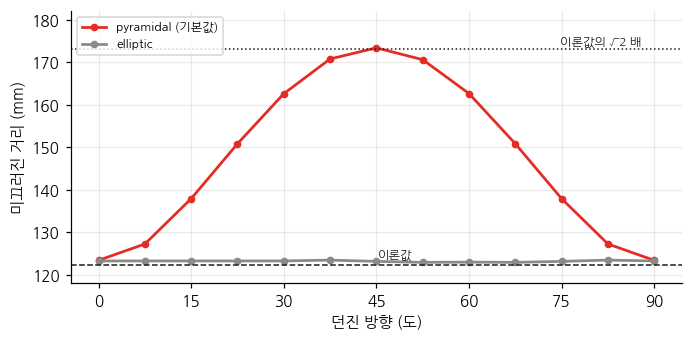

pyramidal 최댓값 173.34 mm (45도)
이론값의 1.4170 배,  √2 = 1.4142
elliptic 은 각도에 따른 편차가 0.531 mm 뿐이다


In [6]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(angles, by_cone["pyramidal"] * 1000, "o-", color=RED,
        lw=1.8, ms=4, label="pyramidal (기본값)")
ax.plot(angles, by_cone["elliptic"] * 1000, "o-", color=GREY,
        lw=1.8, ms=4, label="elliptic")
ax.axhline(THEORY * 1000, ls="--", color=INK, lw=1)
ax.text(48, THEORY * 1000 * 1.012, "이론값", fontsize=8,
        color=INK, ha="center")
ax.axhline(THEORY * np.sqrt(2) * 1000, ls=":", color=INK, lw=1)
ax.text(88, THEORY * np.sqrt(2) * 1000 * 1.005, "이론값의 √2 배",
        fontsize=8, color=INK, ha="right")
ax.set_xlabel("던진 방향 (도)")
ax.set_ylabel("미끄러진 거리 (mm)")
ax.set_xticks(np.arange(0, 91, 15))
ax.legend(fontsize=8, loc="upper left")
ax.set_ylim(118, 182)
plt.tight_layout()
plt.show()

peak = by_cone["pyramidal"].max()
print(f"pyramidal 최댓값 {peak*1000:.2f} mm (45도)")
print(f"이론값의 {peak/THEORY:.4f} 배,  √2 = {np.sqrt(2):.4f}")
spread = (ell.max() - ell.min()) * 1000
print(f"elliptic 은 각도에 따른 편차가 {spread:.3f} mm 뿐이다")

In [7]:
def step_cost(cone, n=20_000, reps=3):
    # 여러 번 재서 최솟값을 쓴다. 평균은 다른 프로세스의
    # 방해를 그대로 먹는다
    m, d = build(cone=cone)
    d.qpos[2] = .031
    d.qvel[0] = V0
    mujoco.mj_forward(m, d)
    for _ in range(500):
        mujoco.mj_step(m, d)
    best = 1e9
    for _ in range(reps):
        t0 = time.perf_counter()
        for _ in range(n):
            mujoco.mj_step(m, d)
        best = min(best, time.perf_counter() - t0)
    return n / best


for cone in ("pyramidal", "elliptic"):
    sps = f"{step_cost(cone):,.0f} 스텝/초"
    print(pad(cone, 14) + pad(sps, 20, True))

pyramidal          184,536 스텝/초


elliptic           189,187 스텝/초


## 솔버 반복수

접촉과 마찰은 제약 조건이고, 엔진은 매 스텝 그 제약을 반복법으로 푼다. 반복을 적게 하면 빠르지만 덜 정확하다. 얼마나 필요한가.

In [8]:
its = [1, 2, 3, 5, 10, 20, 50, 100]
d_it = [slide(np.radians(45), iters=i) for i in its]
ref = d_it[-1]

print(pad("iterations", 14) + pad("거리 (mm)", 12, True)
      + pad("100회 대비", 14, True))
for i, v in zip(its, d_it):
    print(pad(str(i), 14) + pad(f"{v*1000:.3f}", 12, True)
          + pad(f"{(v-ref)*1000:+.3f} mm", 14, True))

iterations       거리 (mm)    100회 대비
1                  169.957     -3.380 mm
2                  173.325     -0.011 mm
3                  173.337     +0.000 mm
5                  173.336     +0.000 mm
10                 173.336     +0.000 mm
20                 173.336     +0.000 mm
50                 173.336     +0.000 mm
100                173.336     +0.000 mm


## 정지 마찰이 없다

마지막이 가장 크게 어긋나는 자리다.

현실의 마찰에는 정지 마찰과 운동 마찰이 따로 있다. 가만히 있는 물체를 밀 때, 미는 힘이 정지 마찰 한계를 넘기 전에는 **물체가 전혀 움직이지 않는다.** 엔진에는 그 구분이 없다. 제약을 무르게 푸는 방식이라 한계 아래의 힘에도 조금씩 밀린다.

마찰 한계의 α배 되는 힘을 5초 동안 가하고 원반이 얼마나 움직이는지 잰다. 현실이라면 α가 1보다 작은 동안은 0이어야 한다.

In [9]:
def creep(alpha, secs=5., dt=.002, cone="pyramidal"):
    m, d = build(cone=cone, dt=dt)
    d.qpos[2] = .031
    mujoco.mj_forward(m, d)
    f = alpha * MU * MASS * G
    for _ in range(int(secs / dt)):
        d.xfrc_applied[1, 0] = f      # 원반에 수평 힘을 건다
        mujoco.mj_step(m, d)
    return float(d.qpos[0])


alphas = [.1, .2, .4, .6, .8, .9, .95, 1.0, 1.1]
mv = [creep(a) for a in alphas]

print(pad("힘 / 마찰 한계", 18) + pad("5초 뒤 이동", 16, True)
      + pad("현실이라면", 14, True))
for a, v in zip(alphas, mv):
    real = "0" if a < 1 else "움직인다"
    print(pad(f"{a:.2f}", 18) + pad(f"{v*1000:.2f} mm", 16, True)
          + pad(real, 14, True))

힘 / 마찰 한계         5초 뒤 이동    현실이라면
0.10                       1.53 mm             0
0.20                       3.06 mm             0
0.40                       6.34 mm             0
0.60                      12.30 mm             0
0.80                      42.35 mm             0
0.90                      74.99 mm             0
0.95                      96.64 mm             0
1.00                    1373.63 mm      움직인다
1.10                   15388.06 mm      움직인다


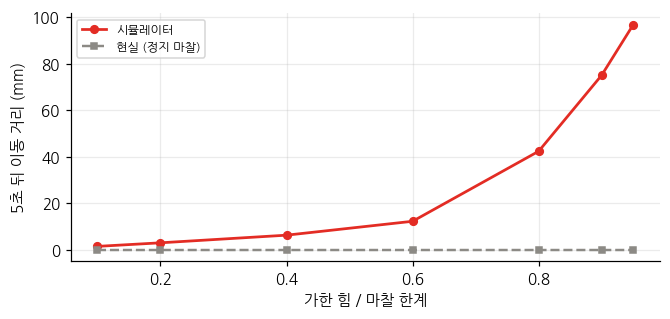

마찰 한계의 20% 힘에도 5초에 3.1 mm 기어간다
80% 에서는 42.4 mm


In [10]:
fig, ax = plt.subplots(figsize=(6.2, 3.0))
sub = [a for a in alphas if a < 1]
ax.plot(sub, [v * 1000 for a, v in zip(alphas, mv) if a < 1], "o-",
        color=RED, lw=1.8, ms=5, label="시뮬레이터")
ax.plot(sub, [0] * len(sub), "s--", color=GREY, lw=1.6, ms=4,
        label="현실 (정지 마찰)")
ax.set_xlabel("가한 힘 / 마찰 한계")
ax.set_ylabel("5초 뒤 이동 거리 (mm)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

print(f"마찰 한계의 20% 힘에도 5초에 {mv[1]*1000:.1f} mm 기어간다")
print(f"80% 에서는 {mv[4]*1000:.1f} mm")

## 정리

**이 노트북에서 바꾼 것 중 물리 모델은 하나도 없다.** 마찰계수도 질량도 형상도 내내 같았다. 바꾼 것은 전부 「엔진이 그 물리를 어떻게 푸는가」에 관한 설정이다. 그런데 답은 최대 41% 달라졌다.

**기본값은 공짜가 아니다.** `cone="pyramidal"`은 대각선 방향 마찰을 √2분의 1로 깎는데, 이 장면에서는 그 대가로 얻는 속도 이득이 없었다. 기본값이 나쁘다는 뜻이 아니라, 그것이 어떤 가정 위에 있는 값인지 알고 써야 한다는 뜻이다.

**어떤 오차는 타임스텝을 줄여도 안 사라진다.** 접촉의 무름은 수치 오차가 아니라 모델의 일부다. 없앨 대상이 아니라 실기에 맞출 대상이고, 그것이 4장의 주제다.

**정지 마찰은 아예 없다.** 이건 맞추는 문제가 아니라 없는 문제다. 정지 마찰에 기대는 과제를 시뮬레이터로 학습시킬 때는 다른 수를 써야 한다.

3장에서는 이런 차이들이 **정책의 순위**를 얼마나 흔드는지를 잰다. 41%라는 숫자가 큰지 작은지는 거기서 답이 나온다.